# Problem 1 notebook : SVI




## Answered Questions
This is an extension of Stochastic Variational Inference with NumPyro from https://phuijse.github.io/BLNNbook/chapters/variational/svi.html

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import numpy as np
import matplotlib.pyplot as plt
import numpyro.distributions as dists
import optax

import numpyro
import numpyro.distributions as dist
from numpyro.distributions import constraints
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal, AutoIAFNormal

from jax import jit
from jax.scipy.special import logsumexp

numpyro.set_platform('cpu')
key = random.PRNGKey(1234)
print('JAX devices:', jax.devices())


JAX devices: [CpuDevice(id=0)]


## Setup and data

In [2]:
def make_data(key, N=60, w_true=0.5, b_true=-0.7, s_true=1.0):
    key, k1, k2 = random.split(key, 3)
    x = dist.Normal(0.0, 5.0).sample(k1, sample_shape=(N,))
    x = jnp.sort(x)
    y = w_true * x + b_true + dist.Normal(0.0, s_true).sample(k2, sample_shape=(N,))
    return key, x, y, (w_true, b_true, s_true)

def shuffle(key, x, y):
    if hasattr(x, 'shape'):
        N = x.shape[0]
    else:
        N = len(x)
    perm = random.permutation(key, N)
    return x[perm], y[perm]

def train_val_split(x, y, ratio=0.8):
    N = x.shape[0]
    n_train = int(N * ratio)
    x, y = shuffle(random.PRNGKey(0), x, y)  # shuffle before splitting
    return (x[:n_train], y[:n_train]), (x[n_train:], y[n_train:])

def plot_data(x, y, title='data'):
    plt.figure(figsize=(6,4))
    plt.scatter(np.array(x), np.array(y), s=15, color='k', alpha=0.7)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()


def run_svi(model, guide, key, *args, lr=1e-2, steps=2000, particles=1):
    svi = SVI(model, guide, optax.adam(lr), Trace_ELBO(num_particles=particles))
    state = svi.init(key, *args)
    jit_update = jit(svi.update)
    losses = []
    for t in range(steps):
        state, loss = jit_update(state, *args)
        losses.append(float(loss))
    return svi, state, jnp.array(losses)


def sample_posterior(model, svi, state, key, x, num_samples=2000, sites=None):
    params = svi.get_params(state)
    predictive = Predictive(model, guide=svi.guide, params=params, num_samples=num_samples, return_sites=sites)
    return predictive(key, x)


def plot_loss(losses, title='SVI loss'):
    plt.figure(figsize=(6,4))
    if isinstance(losses, dict):
        for label, losses in losses.items():
            plt.plot(np.array(losses), label=label)
        # Add legend if multiple lines
        if len(losses) > 1:
            plt.legend()
    elif isinstance(losses, (list, tuple)) and len(losses) > 0 and isinstance(losses[0], tuple):
        # List of tuples
        for label, loss_array in losses:
            plt.plot(np.array(loss_array), label=label)
        # Add legend if multiple lines
        if len(losses) > 1:
            plt.legend()
    else:
        # Single array
        plt.plot(np.array(losses))
    plt.title(title)
    plt.xlabel('step')
    plt.ylabel('loss (negative ELBO)')
    plt.yscale('log')
    plt.show()


def summary_stats(samples_1d):
    # mean, std, 95% CI
    mean = float(jnp.mean(samples_1d))
    std = float(jnp.std(samples_1d))
    lo, hi = jnp.quantile(samples_1d, jnp.array([0.025, 0.975]))
    return mean, std, float(lo), float(hi)


def corrcoef(a, b):
    a = jnp.asarray(a)
    b = jnp.asarray(b)
    a = a - jnp.mean(a)
    b = b - jnp.mean(b)
    return float(jnp.sum(a*b) / (jnp.sqrt(jnp.sum(a*a)) * jnp.sqrt(jnp.sum(b*b)) + 1e-12))


def predictive_band_from_mu(mu_samples, q=(0.05, 0.5, 0.95)):
    qs = jnp.quantile(mu_samples, jnp.array(q), axis=0)
    return qs[0], qs[1], qs[2]


def coverage_from_mu(mu_samples, y_obs, alpha=0.10):
    # Empirical coverage of (1-alpha) interval computed from mu samples
    lo, hi = jnp.quantile(mu_samples, jnp.array([alpha/2, 1-alpha/2]), axis=0)
    covered = (y_obs >= lo) & (y_obs <= hi)
    return float(jnp.mean(covered))


def spearman_corr(x, y):
    # Spearman correlation via rank transform
    x = np.asarray(x)
    y = np.asarray(y)
    rx = x.argsort().argsort().astype(float)
    ry = y.argsort().argsort().astype(float)
    rx = (rx - rx.mean()) / (rx.std() + 1e-12)
    ry = (ry - ry.mean()) / (ry.std() + 1e-12)
    return float((rx*ry).mean())


def track_posterior_means(model, guide, key, x_tr, y_tr, sites, lr=1e-2, steps=2000, every=100, S=200):
    # Train SVI and periodically record posterior means of given sites
    svi = SVI(model, guide, optax.adam(lr), Trace_ELBO())
    state = svi.init(key, x_tr, y_tr)
    jit_update = jit(svi.update)

    t_list = []
    losses = []
    means = {s: [] for s in sites}

    for t in range(steps):
        state, loss = jit_update(state, x_tr, y_tr)
        losses.append(float(loss))
        if (t % every) == 0 or t == steps-1:
            params = svi.get_params(state)
            pred = Predictive(model, guide=svi.guide, params=params, num_samples=S, return_sites=sites)
            samps = pred(random.fold_in(key, t), x_tr)
            for s in sites:
                means[s].append(float(jnp.mean(samps[s])))
            t_list.append(t)

    return svi, state, np.array(losses), np.array(t_list), {k: np.array(v) for k,v in means.items()}


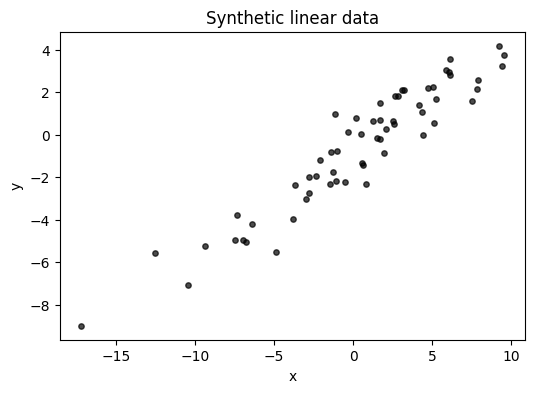

In [3]:
key, x, y, truth = make_data(key)
w_true, b_true, s_true = truth
(x_tr, y_tr), (x_val, y_val) = train_val_split(x, y)
plot_data(x, y, title='Synthetic linear data')


## Baseline model

In [4]:
def lin_model(x, y=None):
    w = numpyro.sample('w', dist.Normal(0.0, 10.0))
    b = numpyro.sample('b', dist.Normal(0.0, 10.0))
    s = numpyro.sample('s_eps', dist.HalfCauchy(10.0))
    mu = numpyro.deterministic('mu', w * x + b)
    with numpyro.plate('data', x.shape[0]):
        numpyro.sample('y', dist.Normal(mu, s), obs=y)
    return mu


## Manual full-covariance guide
This is the code from Stochastic Variational Inference with NumPyro at https://phuijse.github.io/BLNNbook/chapters/variational/svi.html.


In [5]:
def model(x, y=None):
    w = numpyro.sample('w', dist.Normal(0.0, 10.0))
    b = numpyro.sample('b', dist.Normal(0.0, 10.0))
    s = numpyro.sample('s_eps', dist.HalfCauchy(10.0))
    mu = numpyro.deterministic('mu', w * x + b)
    with numpyro.plate('data', x.shape[0]):
        numpyro.sample('y', dist.Normal(mu, s), obs=y)
    return mu


## Implementation of SVI

In [6]:
from numpyro.distributions import constraints

def guide(x, y=None):
    # slope
    w_loc = numpyro.param("w_loc", 0.0)
    w_scale = numpyro.param("w_scale", 0.1, constraint=constraints.positive)
    w = numpyro.sample("w", dists.Normal(w_loc, w_scale), rng_key=key)
    # intercept
    b_loc = numpyro.param("b_loc", 0.0)
    b_scale = numpyro.param("b_scale", 0.1, constraint=constraints.positive)
    b = numpyro.sample("b", dists.Normal(b_loc, b_scale), rng_key=key)
    # noise variance
    s_loc = numpyro.param("s_log_loc", 0.0)
    s_scale = numpyro.param("s_log_scale", 0.1, constraint=constraints.positive)
    s = numpyro.sample("s_eps", dists.TransformedDistribution(dists.Normal(s_loc, s_scale),
                                                          dists.transforms.ExpTransform()))
    return w, b, s


In [7]:
#%%time
import numpyro.distributions as dists
from jax import jit
import optax
from tqdm.notebook import tqdm

def train_svi(guide, key, lr=0.01, nepochs=1000):
    svi = numpyro.infer.SVI(model, guide, optax.adam(lr), loss=numpyro.infer.Trace_ELBO())
    state = svi.init(key, x, y)

    loss_evolution = []
    param_names = list(svi.get_params(state).keys())
    print(param_names)
    param_evolution = {param: [] for param in param_names}

    jit_update = jit(svi.update)
    for epoch in tqdm(range(nepochs)):
        state, loss = jit_update(state, x, y)
        loss_evolution.append(loss.item())
        current_params = svi.get_params(state)
        for name, value in current_params.items():
            param_evolution[name].append(value)

    for name, value in current_params.items():
        param_evolution[name] = jnp.stack(param_evolution[name])
    return svi, state, loss_evolution, param_evolution

key, key_ = random.split(key)
svi, state, loss_evolution, param_evolution = train_svi(guide, key_)

['b_loc', 'b_scale', 's_log_loc', 's_log_scale', 'w_loc', 'w_scale']


  0%|          | 0/1000 [00:00<?, ?it/s]

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
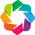

:Curve   [Epoch]   (Loss)

In [8]:
import holoviews as hv
hv.extension('bokeh') # Add this line to load the plotting extension
hv.Curve(loss_evolution, 'Epoch', 'Loss').opts(width=500)

In [9]:


curves = [hv.Curve(param_evolution[name],
                   'Epoch', 'Locations', label=name) for name in ['b_loc', 'w_loc', 's_log_loc']]
loc_plots = hv.Overlay(curves).opts(legend_position='top', width=320)
curves = [hv.Curve(param_evolution[name],
                   'Epoch', 'Scales', label=name) for name in ['b_scale', 'w_scale', 's_log_scale']]
scale_plots = hv.Overlay(curves).opts(legend_position='top', width=320)
loc_plots + scale_plots

:Layout
   .Overlay.I  :Overlay
      .Curve.B_loc     :Curve   [Epoch]   (Locations)
      .Curve.W_loc     :Curve   [Epoch]   (Locations)
      .Curve.S_log_loc :Curve   [Epoch]   (Locations)
   .Overlay.II :Overlay
      .Curve.B_scale     :Curve   [Epoch]   (Scales)
      .Curve.W_scale     :Curve   [Epoch]   (Scales)
      .Curve.S_log_scale :Curve   [Epoch]   (Scales)

In [10]:
predictive = numpyro.infer.Predictive(model,
                                      guide=svi.guide,
                                      params=svi.get_params(state),
                                      return_sites=['w', 'b', 's_eps', 'mu'],
                                      num_samples=1000)

x_test = jnp.linspace(-12, 12, num=100)
posterior_samples = predictive(random.PRNGKey(1), x_test)

def plot_marginals(posterior_samples):
    dist_w = hv.Distribution(posterior_samples['w'], 'w') * hv.VLine(w_true)
    dist_b = hv.Distribution(posterior_samples['b'], 'b') * hv.VLine(b_true)
    dist_s = hv.Distribution(posterior_samples['s_eps'], 's_eps') * hv.VLine(s_true)
    return dist_b + dist_w + dist_s

plot_marginals(posterior_samples)

:Layout
   .Overlay.I   :Overlay
      .Distribution.I :Distribution   [b]   (Density)
      .VLine.I        :VLine   [x,y]
   .Overlay.II  :Overlay
      .Distribution.I :Distribution   [w]   (Density)
      .VLine.I        :VLine   [x,y]
   .Overlay.III :Overlay
      .Distribution.I :Distribution   [s_eps]   (Density)
      .VLine.I        :VLine   [x,y]

## Polynomial regression and coefficient analysis

Model:
$ y = w_0 + w_1 x + w_2 x^2 + \epsilon,\ \epsilon\sim\mathcal N(0,s).$

**Tasks**
1. Implement `poly_model` with sites `w0,w1,w2,s_eps`.
2. Train with (i) `AutoDiagonalNormal` and (ii) `AutoMultivariateNormal`. Plot both loss curves.
3. Plot predictive median + 90% band for both guides.
4. Posterior samples: compute Corr(w1,w2) for both guides and explain why correlation occurs.
5. Plot joint posterior (w1,w2) for both guides.
6. **Beyond ELBO:** record coefficient trajectories over training (posterior means of w0,w1,w2,s_eps at checkpoints) and plot them.


In [11]:
# Define the Poly Model
def poly_model(x, y=None):
    ''' Define the Poly Model: y = w0 + w1*x + w2*x^2 + s'''
    # Explicitly 3 weight terms: w0, w1, w2
    w0 = numpyro.sample("w0", dist.Normal(0.0, 10.0))
    w1 = numpyro.sample("w1", dist.Normal(0.0, 10.0))
    w2 = numpyro.sample("w2", dist.Normal(0.0, 10.0))
    # The noise term
    s = numpyro.sample("s_eps", dist.HalfCauchy(10.0))
    # The mean
    mu = numpyro.deterministic("mu", w0 + w1 * x + w2 * (x ** 2))
    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("y", dist.Normal(mu, s), obs=y)
    return mu

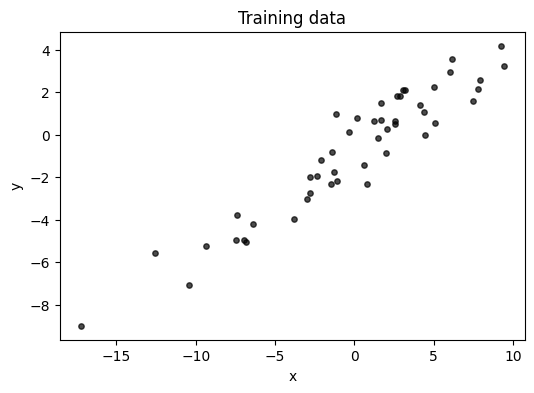

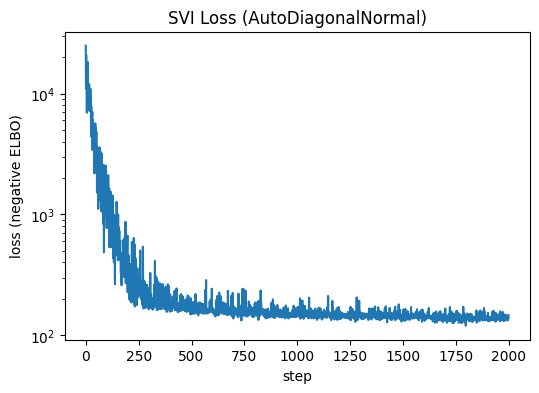

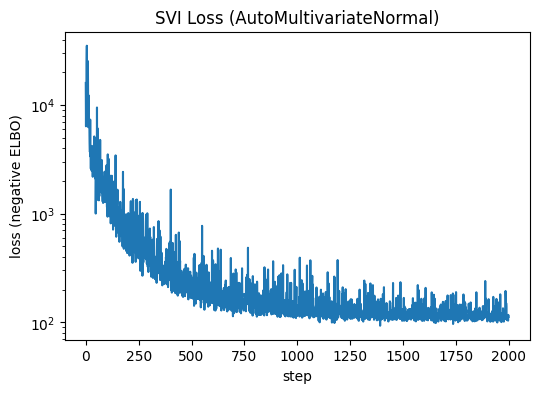

In [12]:
# Guides
guide_auto = AutoDiagonalNormal(poly_model)
guide_mv = AutoMultivariateNormal(poly_model)

# We need 4 different keys for training 2 different guides and predictions (posterior/predictive mean)
key, key1, key2, key3 = random.split(key, 4)

# Train with AutoDiagonalNormal guide
svi_auto, state_auto, losses_auto = run_svi(poly_model, guide_auto, key1, x_tr, y_tr)
# Train with AutoMultivariateNormal guide
svi_mv, state_mv, loss_mv = run_svi(poly_model, guide_mv, key2, x_tr, y_tr)

# Predictions
pred_auto = sample_posterior(poly_model, svi_auto, state_auto, key, x_tr, num_samples=1000, sites=["mu", "w0", "w1", "w2", "s_eps"])
pred_mv   = sample_posterior(poly_model, svi_mv, state_mv, random.PRNGKey(99), x_tr, num_samples=1000, sites=["mu", "w0", "w1", "w2", "s_eps"])
mu_samples_auto = pred_auto['mu']
mu_samples_mv   = pred_mv['mu']
quatile1_auto, quatile2_auto, quatile3_auto = predictive_band_from_mu(mu_samples_auto)
quatile1_mv, quatile2_mv, quatile3_mv = predictive_band_from_mu(mu_samples_mv)

# Visualize Data and Fitting Losses (Training Set)
plot_data(x_tr, y_tr, title='Training data')
plot_loss(losses_auto, title='SVI Loss (AutoDiagonalNormal)')
plot_loss(loss_mv, title='SVI Loss (AutoMultivariateNormal)')

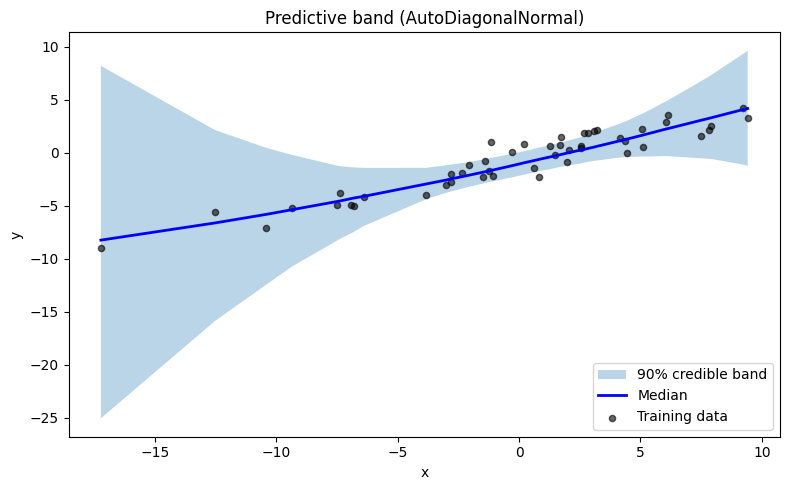

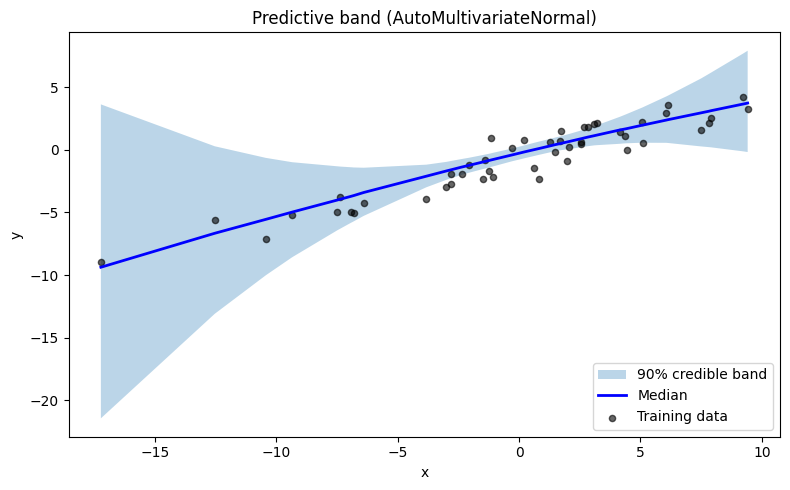

In [13]:
# Plot: Predictive bands from guide vs true data
def plot_predictive_band(x, y, lo, med, hi, title='Predictive band'):
    """
    Plot training data with predictive median and 90% credible band.
    
    Args:
        x: input points (for x-axis)
        y: observed data (scatter plot)
        lo, med, hi: lower, median, upper quantiles from predictive_band_from_mu
        title: plot title
    """
    plt.figure(figsize=(8, 5))
    
    # Sort by x for smooth line plotting
    x_arr = np.array(x)
    sort_idx = np.argsort(x_arr)
    x_sorted = x_arr[sort_idx]
    
    # Predictive band (90% both sides)
    plt.fill_between(x_sorted, np.array(lo)[sort_idx], np.array(hi)[sort_idx], 
                     alpha=0.3, label='90% credible band')
    # Show the Median from predictions
    plt.plot(x_sorted, np.array(med)[sort_idx], 'b-', linewidth=2, label='Median')
    
    # Training data
    plt.scatter(x, y, s=20, color='k', alpha=0.6, label='Training data')
    
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Use the pre-computed quantiles to display the 90% credible interval
plot_predictive_band(x_tr, y_tr, quatile1_auto, quatile2_auto, quatile3_auto, title='Predictive band (AutoDiagonalNormal)')
plot_predictive_band(x_tr, y_tr, quatile1_mv, quatile2_mv, quatile3_mv, title='Predictive band (AutoMultivariateNormal)')

In [14]:
# Correlation between w1 and w2 samples
w1_samples_auto, w1_samples_mv = pred_auto['w1'], pred_mv['w1']
w2_samples_auto, w2_samples_mv = pred_auto['w2'], pred_mv['w2']
# Uses Spearman correlation - not necessarily for linear relationships (More Robust!)
corr_auto = spearman_corr(w1_samples_auto, w2_samples_auto)
corr_mv = spearman_corr(w1_samples_mv, w2_samples_mv)
print(f"Correlation between w1 and w2 (AutoDiagonalNormal): {corr_auto:.3f}")
print(f"Correlation between w1 and w2 (AutoMultivariateNormal): {corr_mv:.3f}")

Correlation between w1 and w2 (AutoDiagonalNormal): 0.052
Correlation between w1 and w2 (AutoMultivariateNormal): 0.082


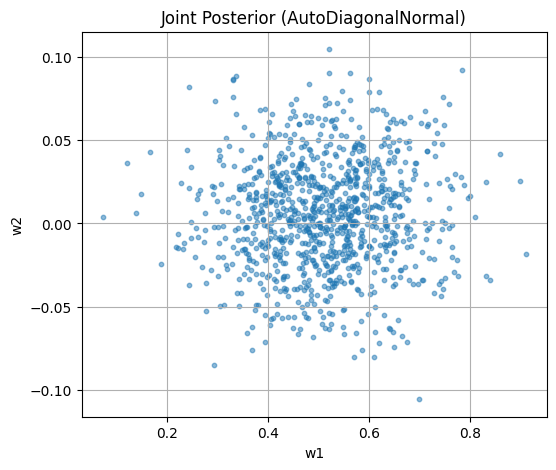

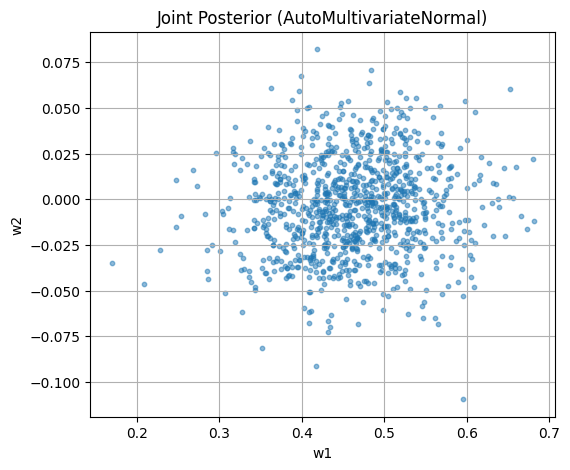

In [15]:
# Plot: Joint Posterior
def plot_joint_posterior(w1_samples, w2_samples, title='Joint Posterior of w1 and w2'):
    plt.figure(figsize=(6, 5))
    plt.scatter(w1_samples, w2_samples, s=10, alpha=0.5)
    plt.title(title)
    plt.xlabel('w1')
    plt.ylabel('w2')
    plt.grid(True)
plot_joint_posterior(w1_samples_auto, w2_samples_auto, title='Joint Posterior (AutoDiagonalNormal)')
plot_joint_posterior(w1_samples_mv, w2_samples_mv, title='Joint Posterior (AutoMultivariateNormal)')

6. **Beyond ELBO:** record coefficient trajectories over training (posterior means of w0,w1,w2,s_eps at checkpoints) and plot them.

In [16]:
# Posterior Means
# AutoDiagonalNormal guide
w0_mean_auto = float(jnp.mean(pred_auto['w0']))
w1_mean_auto = float(jnp.mean(pred_auto['w1']))
w2_mean_auto = float(jnp.mean(pred_auto['w2']))
s_mean_auto = float(jnp.mean(pred_auto['s_eps']))
# AutoMultivariateNormal guide
w0_mean_mv = float(jnp.mean(pred_mv['w0']))
w1_mean_mv = float(jnp.mean(pred_mv['w1']))
w2_mean_mv = float(jnp.mean(pred_mv['w2']))
s_mean_mv = float(jnp.mean(pred_mv['s_eps']))
print(f"Posterior means (AutoDiagonalNormal): w0={w0_mean_auto:.3f}, w1={w1_mean_auto:.3f}, w2={w2_mean_auto:.3f}, s={s_mean_auto:.3f}")
print(f"Posterior means (AutoMultivariateNormal): w0={w0_mean_mv:.3f}, w1={w1_mean_mv:.3f}, w2={w2_mean_mv:.3f}, s={s_mean_mv:.3f}")

# Plot
def plot_marginals(posterior_samples):
    dist_w0 = hv.Distribution(posterior_samples['w0'], 'w0') * hv.VLine(w_true)
    dist_w1 = hv.Distribution(posterior_samples['w1'], 'w1') * hv.VLine(w_true)
    dist_w2 = hv.Distribution(posterior_samples['w2'], 'w2') * hv.VLine(w_true)
    dist_s = hv.Distribution(posterior_samples['s_eps'], 's_eps') * hv.VLine(s_true)
    return dist_w0 + dist_w1 + dist_w2 + dist_s
plot_marginals(pred_auto)
plot_marginals(pred_mv)

Posterior means (AutoDiagonalNormal): w0=-1.066, w1=0.511, w2=0.005, s=4.680
Posterior means (AutoMultivariateNormal): w0=-0.278, w1=0.461, w2=-0.004, s=2.220


:Layout
   .Overlay.I   :Overlay
      .Distribution.I :Distribution   [w0]   (Density)
      .VLine.I        :VLine   [x,y]
   .Overlay.II  :Overlay
      .Distribution.I :Distribution   [w1]   (Density)
      .VLine.I        :VLine   [x,y]
   .Overlay.III :Overlay
      .Distribution.I :Distribution   [w2]   (Density)
      .VLine.I        :VLine   [x,y]
   .Overlay.IV  :Overlay
      .Distribution.I :Distribution   [s_eps]   (Density)
      .VLine.I        :VLine   [x,y]

## Student-t likelihood (robust noise)

Replace Normal likelihood with Student-t (df=4):
$ y_i \sim \mathrm{StudentT}(
u=4,\ 	loc=\mu_i,\ 	scale=s).$

**Tasks**
1. Implement `studentt_model` and train SVI.
2. Compare loss curves to Gaussian baseline.
3. Compare posterior histograms of `s_eps` (Gaussian vs Student-t).
4. **Outlier experiment:** add 3 strong outliers (e.g., +12) to random y-values. Refit both models; compare `s_eps` posterior and predictive bands.
5. Compute coverage of the 90% predictive interval on training points (with and without outliers).


In [17]:
def student_t_model(x, y=None):
    w0 = numpyro.sample("w0", dist.Normal(0.0, 10.0))
    w1 = numpyro.sample("w1", dist.Normal(0.0, 10.0))
    w2 = numpyro.sample("w2", dist.Normal(0.0, 10.0))
    s = numpyro.sample("s_eps", dist.HalfCauchy(10.0))
    nu = numpyro.sample("nu", dist.Exponential(4.0))  # degrees of freedom for Student-t
    mu = numpyro.deterministic("mu", w0 + w1 * x + w2 * (x ** 2))
    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("y", dist.StudentT(nu, mu, s), obs=y)
    return mu

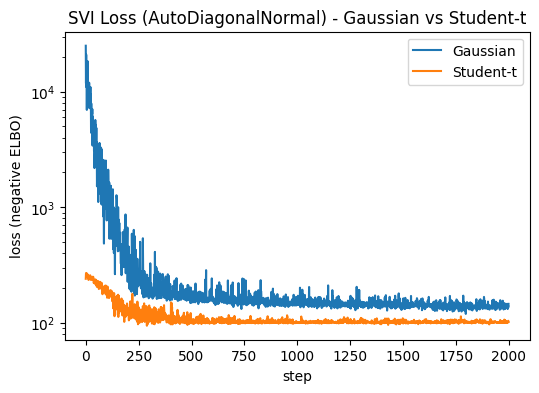

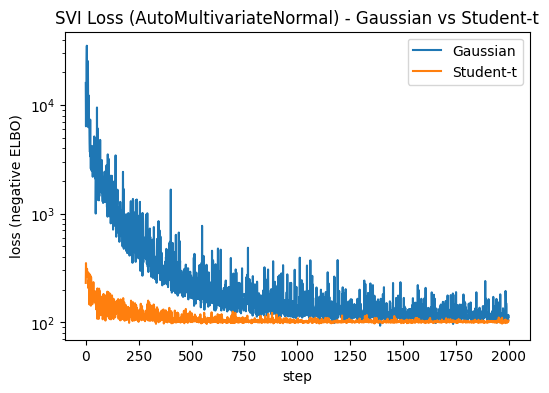

In [18]:
# Guides
guide_auto_t = AutoDiagonalNormal(student_t_model)
guide_mv_t = AutoMultivariateNormal(student_t_model)

# We need 4 different keys for training 2 different guides and predictions (posterior/predictive mean)
key, key1, key2, key3 = random.split(key, 4)

# Train with AutoDiagonalNormal guide
svi_auto_t, state_auto_t, losses_auto_t = run_svi(student_t_model, guide_auto_t, key1, x_tr, y_tr)
# Train with AutoMultivariateNormal guide
svi_mv_t, state_mv_t, loss_mv_t = run_svi(student_t_model, guide_mv_t, key2, x_tr, y_tr)

# Plot: Comparing Losses
plot_loss({
        'Gaussian': losses_auto,
        'Student-t': losses_auto_t
    }, title='SVI Loss (AutoDiagonalNormal) - Gaussian vs Student-t'
)
plot_loss({
        'Gaussian': loss_mv,
        'Student-t': loss_mv_t
    }, title='SVI Loss (AutoMultivariateNormal) - Gaussian vs Student-t'
)

### Observations:
* The loss in a student-t distribution starts lower than that in a Gaussian, for both AutoDiagonalNormal and AutoMultivariateNormal guides. 
* Student-t Distribution converges till a slightly higher loss than Gaussian at **AutoDiagonalNormal** guide. 
* Student-t Distribution converges till a generally lower loss than Gaussian at **AutoMultivariateNormal** guide. 

Estimated noise scale s (AutoDiagonalNormal, Student-t): 0.817
Estimated noise scale s (AutoMultivariateNormal, Student-t): 0.802


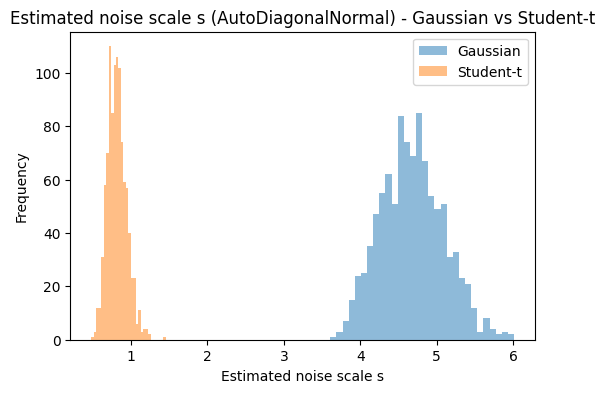

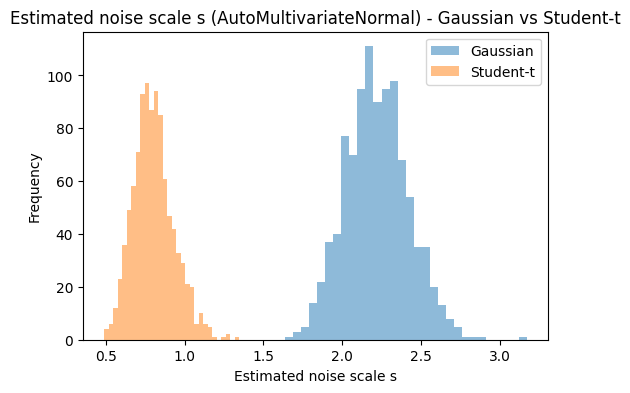

In [19]:
s_eps_auto_t = sample_posterior(student_t_model, svi_auto_t, state_auto_t, key3, x_tr, num_samples=1000, sites=["s_eps"])['s_eps']
print(f"Estimated noise scale s (AutoDiagonalNormal, Student-t): {jnp.mean(s_eps_auto_t):.3f}")
s_eps_mv_t = sample_posterior(student_t_model, svi_mv_t, state_mv_t, random.PRNGKey(88), x_tr, num_samples=1000, sites=["s_eps"])['s_eps']
print(f"Estimated noise scale s (AutoMultivariateNormal, Student-t): {jnp.mean(s_eps_mv_t):.3f}")

# Plot: Compare Gaussian vs Student-t
def compare(sample_posteriors: dict, title='Comparison of s_eps'):
    plt.figure(figsize=(6,4))
    plt.title(title)
    for label, samples in sample_posteriors.items():
        plt.hist(samples, alpha=0.5, label=label, bins=30)
    plt.xlabel('Estimated noise scale s')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

key, key1, key2 = random.split(key, 3)
compare(
    {
        "Gaussian": pred_auto["s_eps"],
        "Student-t": s_eps_auto_t,
    },
    title='Estimated noise scale s (AutoDiagonalNormal) - Gaussian vs Student-t'
)
compare(
    {
        "Gaussian": pred_mv["s_eps"],
        "Student-t": s_eps_mv_t,
    },
    title='Estimated noise scale s (AutoMultivariateNormal) - Gaussian vs Student-t'
)

### Observations:
* In both models, student-t distribution shows less noise in general. 
* Student-t distribution appears narrower than Gaussian's.

### Outlier Experiment

4. **Outlier experiment:** add 3 strong outliers (e.g., +12) to random y-values. Refit both models; compare `s_eps` posterior and predictive bands.
5. Compute coverage of the 90% predictive interval on training points (with and without outliers).

Mean of x_tr: -0.046
Std of x_tr: 5.696
Outliers added to x_tr: [ 11.345358 -11.437536  56.911148]


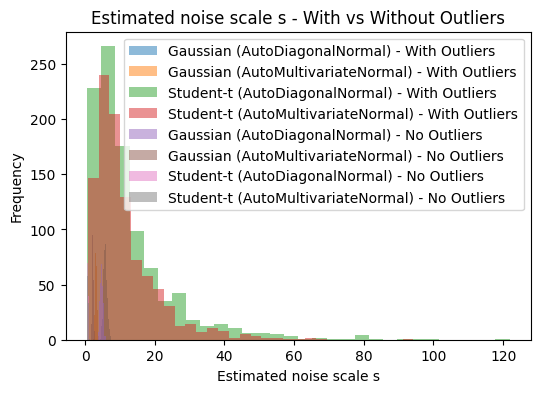

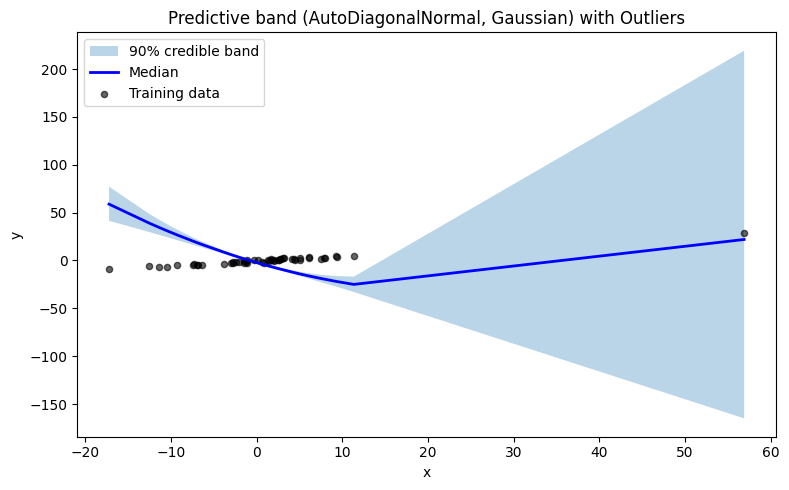

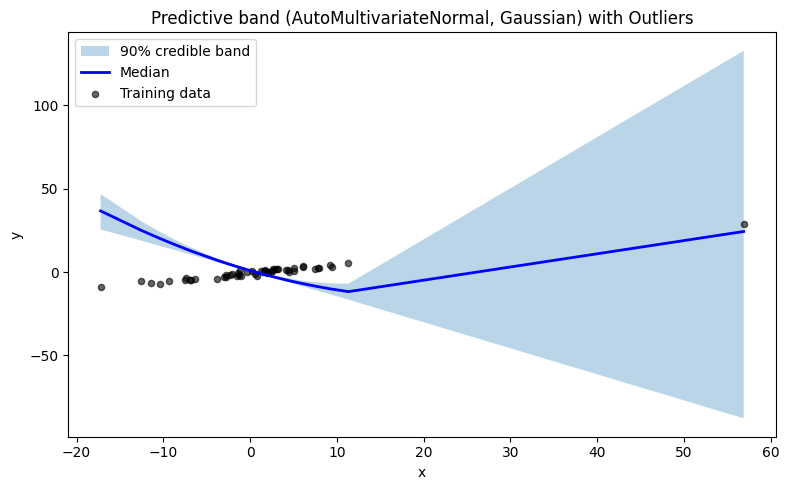

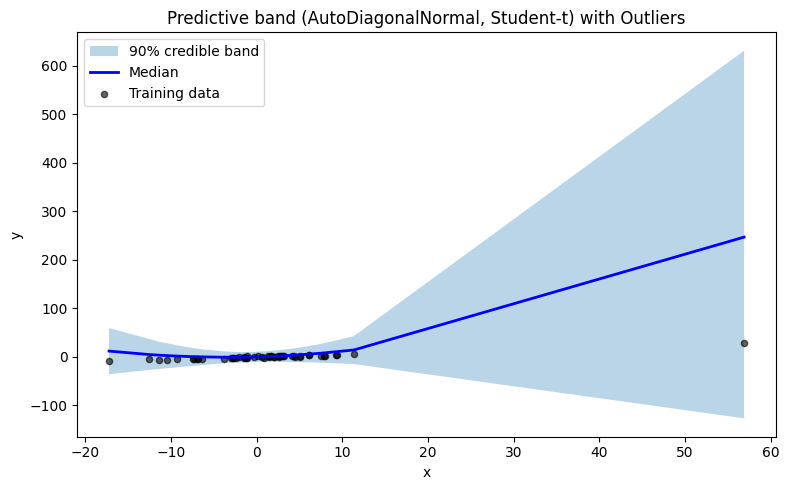

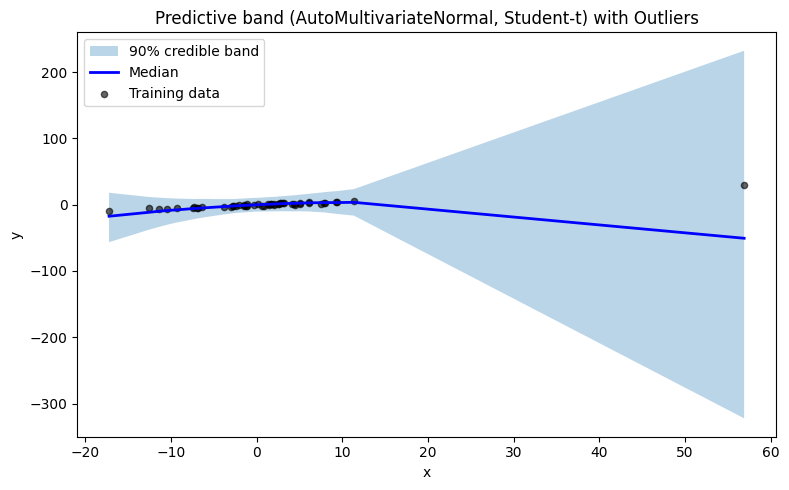

In [20]:
# Find mean and std
x_tr_mean = jnp.mean(x_tr, axis=0)
x_tr_std = jnp.std(x_tr, axis=0)
print(f"Mean of x_tr: {x_tr_mean:.3f}")
print(f"Std of x_tr: {x_tr_std:.3f}")

# Populate three outliers into the training data based on mean and std
x_tr_outliers = jnp.array([x_tr_mean + 2 * x_tr_std, x_tr_mean - 2* x_tr_std, x_tr_mean + 10 * x_tr_std])
y_tr_outliers = jnp.array([jnp.mean(y_tr) + 2 * jnp.std(y_tr), jnp.mean(y_tr) - 2 * jnp.std(y_tr), jnp.mean(y_tr) + 10 * jnp.std(y_tr)])
print(f"Outliers added to x_tr: {x_tr_outliers}")

# Refit Models with outliers
key, key1, key2, key3, key4 = random.split(key, 5)
svi_auto_outliers, state_auto_outliers, losses_auto_outliers = run_svi(poly_model, guide_auto, key1, x_tr_outliers, y_tr_outliers)
svi_mv_outliers, state_mv_outliers, loss_mv_outliers = run_svi(poly_model, guide_mv, key2, x_tr_outliers, y_tr_outliers)
svi_auto_t_outliers, state_auto_t_outliers, losses_auto_t_outliers = run_svi(student_t_model, guide_auto_t, key1, x_tr_outliers, y_tr_outliers)
svi_mv_t_outliers, state_mv_t_outliers, loss_mv_t_outliers = run_svi(student_t_model, guide_mv_t, key2, x_tr_outliers, y_tr_outliers)

# Plot: Comparing noise s with outliers
comparison: dict = {
    # With Outliers
    "Gaussian (AutoDiagonalNormal) - With Outliers": sample_posterior(poly_model, svi_auto_outliers, state_auto_outliers, key3, x_tr_outliers, num_samples=1000, sites=["s_eps"])['s_eps'],
    "Gaussian (AutoMultivariateNormal) - With Outliers": sample_posterior(poly_model, svi_mv_outliers, state_mv_outliers, random.PRNGKey(88), x_tr_outliers, num_samples=1000, sites=["s_eps"])['s_eps'],
    "Student-t (AutoDiagonalNormal) - With Outliers": sample_posterior(student_t_model, svi_auto_t_outliers, state_auto_t_outliers, key3, x_tr_outliers, num_samples=1000, sites=["s_eps"])['s_eps'],
    "Student-t (AutoMultivariateNormal) - With Outliers": sample_posterior(student_t_model, svi_mv_t_outliers, state_mv_t_outliers, random.PRNGKey(88), x_tr_outliers, num_samples=1000, sites=["s_eps"])['s_eps'],
    # Without Outliers
    "Gaussian (AutoDiagonalNormal) - No Outliers": pred_auto["s_eps"],
    "Gaussian (AutoMultivariateNormal) - No Outliers": pred_mv["s_eps"],
    "Student-t (AutoDiagonalNormal) - No Outliers": s_eps_auto_t,
    "Student-t (AutoMultivariateNormal) - No Outliers": s_eps_mv_t,
}
compare(comparison, title='Estimated noise scale s - With vs Without Outliers')

# Plot: Compare predictive bands with outliers
# Combine original training data with outliers for visualization
x_tr_combined = jnp.concatenate([x_tr, x_tr_outliers])
y_tr_combined = jnp.concatenate([y_tr, y_tr_outliers])

# Recompute predictive bands for the outlier models on combined data
pred_auto_outliers = sample_posterior(poly_model, svi_auto_outliers, state_auto_outliers, key3, x_tr_combined, num_samples=1000, sites=["mu"])
pred_mv_outliers = sample_posterior(poly_model, svi_mv_outliers, state_mv_outliers, key4, x_tr_combined, num_samples=1000, sites=["mu"])
pred_auto_outliers_t = sample_posterior(student_t_model, svi_auto_t_outliers, state_auto_t_outliers, key3, x_tr_combined, num_samples=1000, sites=["mu"])
pred_mv_outliers_t = sample_posterior(student_t_model, svi_mv_t_outliers, state_mv_t_outliers, key4, x_tr_combined, num_samples=1000, sites=["mu"])
mu_samples_auto_outliers = pred_auto_outliers['mu']
mu_samples_mv_outliers = pred_mv_outliers['mu']
mu_samples_auto_outliers_t = pred_auto_outliers_t['mu']
mu_samples_mv_outliers_t = pred_mv_outliers_t['mu']
quatile1_auto_outliers, quatile2_auto_outliers, quatile3_auto_outliers = predictive_band_from_mu(mu_samples_auto_outliers)
quatile1_mv_outliers, quatile2_mv_outliers, quatile3_mv_outliers = predictive_band_from_mu(mu_samples_mv_outliers)
quantile1_auto_outliers_t, quatile2_auto_outliers_t, quatile3_auto_outliers_t = predictive_band_from_mu(mu_samples_auto_outliers_t)
quantile1_mv_outliers_t, quatile2_mv_outliers_t, quatile3_mv_outliers_t = predictive_band_from_mu(mu_samples_mv_outliers_t)

plot_predictive_band(x_tr_combined, y_tr_combined, quatile1_auto_outliers, quatile2_auto_outliers, quatile3_auto_outliers, title='Predictive band (AutoDiagonalNormal, Gaussian) with Outliers')
plot_predictive_band(x_tr_combined, y_tr_combined, quatile1_mv_outliers, quatile2_mv_outliers, quatile3_mv_outliers, title='Predictive band (AutoMultivariateNormal, Gaussian) with Outliers')
plot_predictive_band(x_tr_combined, y_tr_combined, quantile1_auto_outliers_t, quatile2_auto_outliers_t, quatile3_auto_outliers_t, title='Predictive band (AutoDiagonalNormal, Student-t) with Outliers')
plot_predictive_band(x_tr_combined, y_tr_combined, quantile1_mv_outliers_t, quatile2_mv_outliers_t, quatile3_mv_outliers_t, title='Predictive band (AutoMultivariateNormal, Student-t) with Outliers')

### Observations:
* For Gaussian models, most samples are not well fitted onto the model now. 
* The prediction bands are obviously wider at the tail.
* Samples fitted well on the student-t distribution.

### Conclusion: 
* Student-t seems more robust, with less noise that allows a model to fit more samples. 

In [21]:
# Training Points covered within the predictive bands
print("Coverage of training points within predictive bands:\n")
print("With Outliers...")
coverage_auto_outliers = coverage_from_mu(mu_samples_auto_outliers, y_tr_combined, alpha=0.10)
coverage_mv_outliers = coverage_from_mu(mu_samples_mv_outliers, y_tr_combined, alpha=0.10)
coverage_auto_outliers_t = coverage_from_mu(mu_samples_auto_outliers_t, y_tr_combined, alpha=0.10)
coverage_mv_outliers_t = coverage_from_mu(mu_samples_mv_outliers_t, y_tr_combined, alpha=0.10)
print(f"Empirical coverage of 90% predictive band (AutoDiagonalNormal, Gaussian) with Outliers: {coverage_auto_outliers:.3f}")
print(f"Empirical coverage of 90% predictive band (AutoMultivariateNormal, Gaussian) with Outliers: {coverage_mv_outliers:.3f}")
print(f"Empirical coverage of 90% predictive band (AutoDiagonalNormal, Student-t) with Outliers: {coverage_auto_outliers_t:.3f}")
print(f"Empirical coverage of 90% predictive band (AutoMultivariateNormal, Student-t) with Outliers: {coverage_mv_outliers_t:.3f}")

print("\nWithout Outliers...")
coverage_auto = coverage_from_mu(mu_samples_auto, y_tr, alpha=0.10)
coverage_mv = coverage_from_mu(mu_samples_mv, y_tr, alpha=0.10)
mu_samples_auto_t_no_outliers = sample_posterior(student_t_model, svi_auto_t, state_auto_t, key3, x_tr, num_samples=1000, sites=["mu"])['mu']
mu_samples_mv_t_no_outliers = sample_posterior(student_t_model, svi_mv_t, state_mv_t, random.PRNGKey(88), x_tr, num_samples=1000, sites=["mu"])['mu']
coverage_auto_t = coverage_from_mu(mu_samples_auto_t_no_outliers, y_tr, alpha=0.10)
coverage_mv_t = coverage_from_mu(mu_samples_mv_t_no_outliers, y_tr, alpha=0.10)
print(f"Empirical coverage of 90% predictive band (AutoDiagonalNormal, Gaussian) without Outliers: {coverage_auto:.3f}")
print(f"Empirical coverage of 90% predictive band (AutoMultivariateNormal, Gaussian) without Outliers: {coverage_mv:.3f}")
print(f"Empirical coverage of 90% predictive band (AutoDiagonalNormal, Student-t) without Outliers: {coverage_auto_t:.3f}")
print(f"Empirical coverage of 90% predictive band (AutoMultivariateNormal, Student-t) without Outliers: {coverage_mv_t:.3f}")

Coverage of training points within predictive bands:

With Outliers...
Empirical coverage of 90% predictive band (AutoDiagonalNormal, Gaussian) with Outliers: 0.039
Empirical coverage of 90% predictive band (AutoMultivariateNormal, Gaussian) with Outliers: 0.039
Empirical coverage of 90% predictive band (AutoDiagonalNormal, Student-t) with Outliers: 1.000
Empirical coverage of 90% predictive band (AutoMultivariateNormal, Student-t) with Outliers: 1.000

Without Outliers...
Empirical coverage of 90% predictive band (AutoDiagonalNormal, Gaussian) without Outliers: 0.812
Empirical coverage of 90% predictive band (AutoMultivariateNormal, Gaussian) without Outliers: 0.583
Empirical coverage of 90% predictive band (AutoDiagonalNormal, Student-t) without Outliers: 0.292
Empirical coverage of 90% predictive band (AutoMultivariateNormal, Student-t) without Outliers: 0.292


## Heteroscedastic noise and learned noise curve

Noise model:
$ s(x)=\exp(ax+c),\quad y_i\sim\mathcal N(wx_i+b,\ s(x_i)).$

**Tasks**
1. Implement `hetero_model` with sites `w,b,a,c` and train with an autoguide.
2. Plot the loss curve and report posterior mean/std for `w,b,a,c`.
3. Using posterior samples, compute and plot median and 90% band for the function `s(x)` on a dense grid.
4. Compare predictive bands to homoscedastic baseline.
5. Discuss one identifiability/optimization challenge.


In [22]:
def noise_model(x, y=None):
    w = numpyro.sample("w", dist.Normal(0.0, 10.0))
    b = numpyro.sample("b", dist.Normal(0.0, 10.0))
    a = numpyro.sample("a", dist.Normal(0.0, 10.0))
    c = numpyro.sample("c", dist.Normal(0.0, 10.0))

    mu = numpyro.deterministic("mu", w * x + b)
    s = numpyro.deterministic("s", jnp.exp(a * x + c)) # avoid 0.0

    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("y", dist.Normal(mu, s), obs=y)
    
    return mu, s

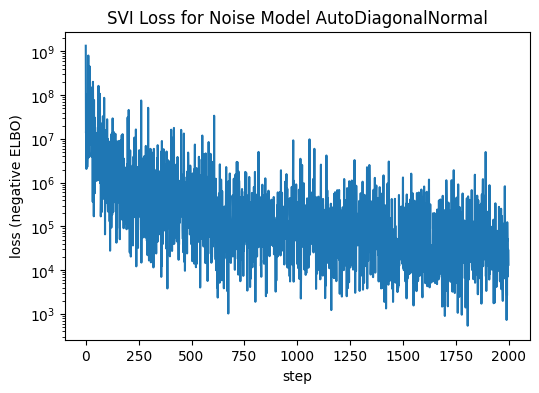

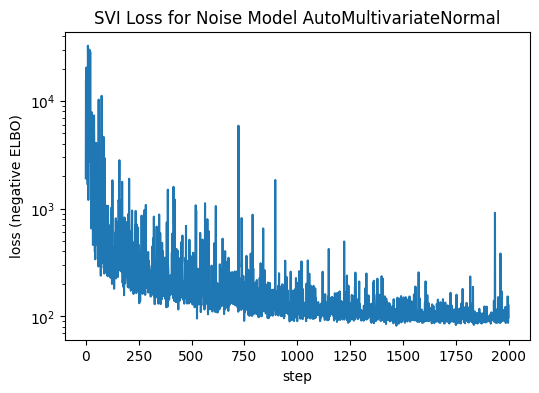

Posterior means for noise model (AutoDiagonalNormal):
w: 0.502, b: -1.122, a: -0.738, c: 1.536
Posterior means for noise model (AutoMultivariateNormal):
w: 0.459, b: -0.718, a: -0.033, c: -0.186


In [23]:
key, key1, key2, key3, key4 = random.split(key, 5)

# Train the model
guide_noise_auto = AutoDiagonalNormal(noise_model)
guide_noise_mv = AutoMultivariateNormal(noise_model)
svi_noise_auto, state_noise_auto, losses_noise_auto = run_svi(noise_model, guide_noise_auto, key1, x_tr, y_tr)
svi_noise_mv, state_noise_mv, losses_noise_mv = run_svi(noise_model, guide_noise_mv, key2, x_tr, y_tr)

# Plot Losses
plot_loss(losses_noise_auto, title=f'SVI Loss for Noise Model AutoDiagonalNormal')
plot_loss(losses_noise_mv, title=f'SVI Loss for Noise Model AutoMultivariateNormal')

# Sample from the posterior
pred_noise_auto = sample_posterior(noise_model, svi_noise_auto, state_noise_auto, key3, x_tr, num_samples=1000, sites=["w", "b", "a", "c", "mu", "s"])
pred_noise_mv = sample_posterior(noise_model, svi_noise_mv, state_noise_mv, key4, x_tr, num_samples=1000, sites=["w", "b", "a", "c", "mu", "s"])
print("Posterior means for noise model (AutoDiagonalNormal):")
print(f"w: {jnp.mean(pred_noise_auto['w']):.3f}, b: {jnp.mean(pred_noise_auto['b']):.3f}, a: {jnp.mean(pred_noise_auto['a']):.3f}, c: {jnp.mean(pred_noise_auto['c']):.3f}")
print("Posterior means for noise model (AutoMultivariateNormal):")
print(f"w: {jnp.mean(pred_noise_mv['w']):.3f}, b: {jnp.mean(pred_noise_mv['b']):.3f}, a: {jnp.mean(pred_noise_mv['a']):.3f}, c: {jnp.mean(pred_noise_mv['c']):.3f}")

Prediction Band quantiles (AutoDiagonalNormal): 5%=-11.290, 50%=-9.789, 95%=-8.078
Prediction Band quantiles (AutoMultivariateNormal): 5%=-10.210, 50%=-8.689, 95%=-6.989


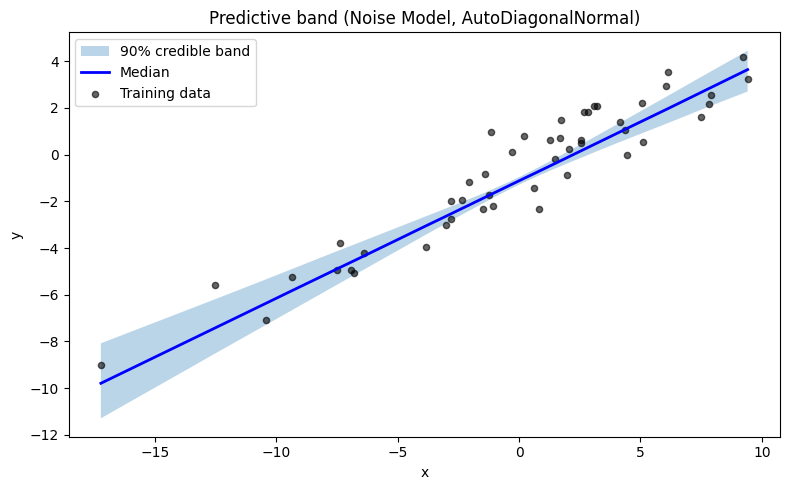

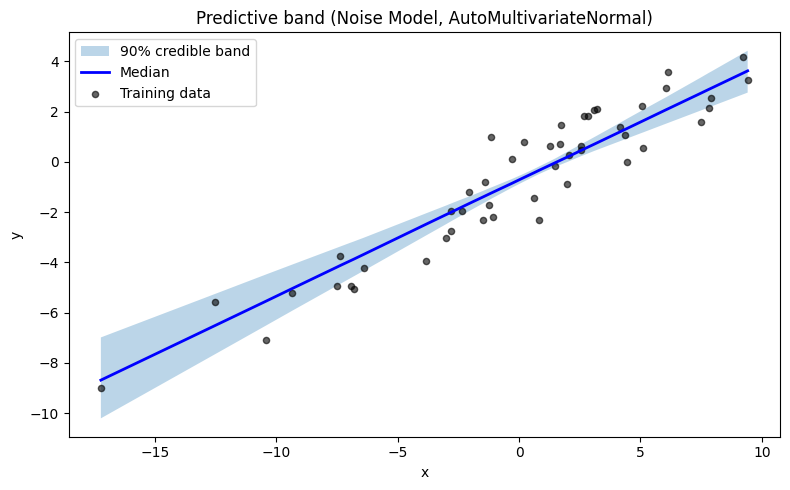

In [24]:
quantile1_noise_auto, quantile2_noise_auto, quantile3_noise_auto = predictive_band_from_mu(pred_noise_auto['mu'])
quantile1_noise_mv, quantile2_noise_mv, quantile3_noise_mv = predictive_band_from_mu(pred_noise_mv['mu'])
print(f"Prediction Band quantiles (AutoDiagonalNormal): 5%={quantile1_noise_auto[0]:.3f}, 50%={quantile2_noise_auto[0]:.3f}, 95%={quantile3_noise_auto[0]:.3f}")
print(f"Prediction Band quantiles (AutoMultivariateNormal): 5%={quantile1_noise_mv[0]:.3f}, 50%={quantile2_noise_mv[0]:.3f}, 95%={quantile3_noise_mv[0]:.3f}")
plot_predictive_band(x_tr, y_tr, quantile1_noise_auto, quantile2_noise_auto, quantile3_noise_auto, title='Predictive band (Noise Model, AutoDiagonalNormal)')
plot_predictive_band(x_tr, y_tr, quantile1_noise_mv, quantile2_noise_mv, quantile3_noise_mv, title='Predictive band (Noise Model, AutoMultivariateNormal)')

### Observations:
* The prediction band is narrower at the **AutoMultivariateNormal** model.
* Samples are closer to the fitted model at the **AutoDiagonalNormal** model.
* **AutoDiagonalNormal** has an increasing median while **AutoMultivariateNormal** has a decreasing median.

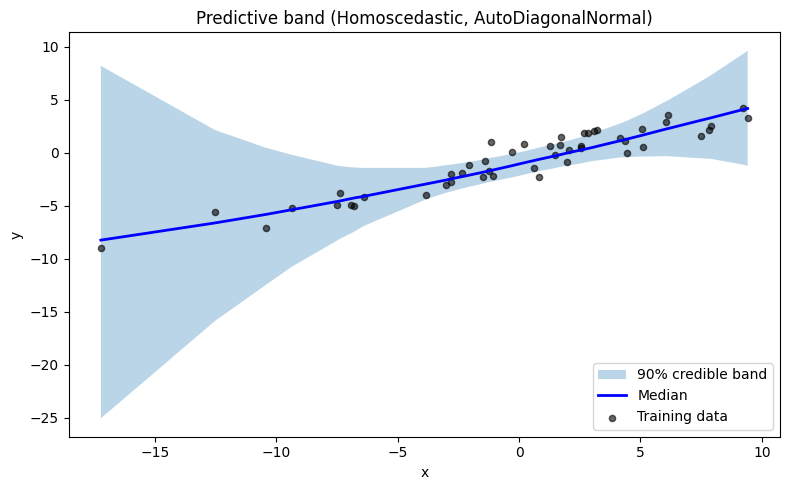

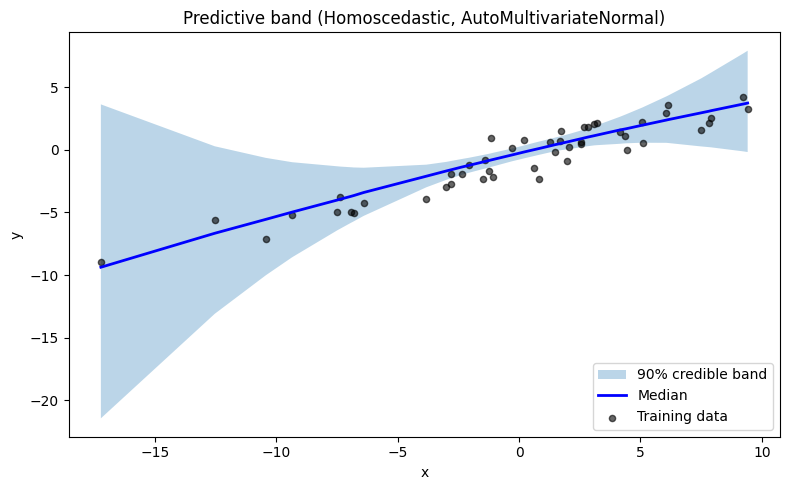

Empirical coverage of 90% predictive band (Homoscedastic, AutoDiagonalNormal): 0.8125
Empirical coverage of 90% predictive band (Homoscedastic, AutoMultivariateNormal): 0.5833333730697632
Empirical coverage of 90% predictive band (Noise Model, AutoDiagonalNormal): 0.3125
Empirical coverage of 90% predictive band (Noise Model, AutoMultivariateNormal): 0.3333333432674408


In [25]:
# Homoscedastic (constant noise)
quatile1_auto, quatile2_auto, quatile3_auto = predictive_band_from_mu(mu_samples_auto)
quatile1_mv, quatile2_mv, quatile3_mv = predictive_band_from_mu(mu_samples_mv)
plot_predictive_band(x_tr, y_tr, quatile1_auto, quatile2_auto, quatile3_auto, title='Predictive band (Homoscedastic, AutoDiagonalNormal)')
plot_predictive_band(x_tr, y_tr, quatile1_mv, quatile2_mv, quatile3_mv, title='Predictive band (Homoscedastic, AutoMultivariateNormal)')
print("Empirical coverage of 90% predictive band (Homoscedastic, AutoDiagonalNormal):", coverage_from_mu(mu_samples_auto, y_tr, alpha=0.10))
print("Empirical coverage of 90% predictive band (Homoscedastic, AutoMultivariateNormal):", coverage_from_mu(mu_samples_mv, y_tr, alpha=0.10))

# Heteroscedastic (input-dependent noise)
print("Empirical coverage of 90% predictive band (Noise Model, AutoDiagonalNormal):", coverage_from_mu(pred_noise_auto['mu'], y_tr, alpha=0.10))
print("Empirical coverage of 90% predictive band (Noise Model, AutoMultivariateNormal):", coverage_from_mu(pred_noise_mv['mu'], y_tr, alpha=0.10))

In [26]:
# Comparing w, b, a, c between the two noise models
corr_auto_wb = spearman_corr(pred_noise_auto['w'], pred_noise_auto['b'])
corr_auto_ac = spearman_corr(pred_noise_auto['a'], pred_noise_auto['c'])
corr_mv_wb = spearman_corr(pred_noise_mv['w'], pred_noise_mv['b'])
corr_mv_ac = spearman_corr(pred_noise_mv['a'], pred_noise_mv['c'])
# Noise Models
print(f"Correlation between w and b (Noise Model, AutoDiagonalNormal): {corr_auto_wb:.3f}")
print(f"Correlation between a and c (Noise Model, AutoDiagonalNormal): {corr_auto_ac:.3f}")
print(f"Correlation between w and b (Noise Model, AutoMultivariateNormal): {corr_mv_wb:.3f}")
print(f"Correlation between a and c (Noise Model, AutoMultivariateNormal): {corr_mv_ac:.3f}")

Correlation between w and b (Noise Model, AutoDiagonalNormal): 0.008
Correlation between a and c (Noise Model, AutoDiagonalNormal): -0.033
Correlation between w and b (Noise Model, AutoMultivariateNormal): -0.284
Correlation between a and c (Noise Model, AutoMultivariateNormal): -0.044


### Observations - Identifiable Optimizing Challenge
* Introducing noise to the model makes the credible interval less likely to accurately fit most samples.
* `w` and `b`, as part of the posterior mean, are negatively correlated in **AutoDiagonalNormal**, but positively correlated in **AutoMultivariateNormal**. 
* `a` and `c`, as part of the noise factor, are positively correlated in **AutoDiagonalNormal**, but negatively correlated in **AutoMultivariateNormal**.

## Hierarchical prior on w and b

Model:
$\alpha\sim\mathcal N(0,10^2),\ 	au\sim\mathrm{HalfCauchy}(5),\ w\sim\mathcal N(\alpha,	au),\ b\sim\mathcal N(\alpha,	au).$

**Tasks**
1. Implement the hierarchical model with sites `alpha, tau, w, b, s_eps`.
2. Train SVI (recommended: `AutoMultivariateNormal`) and plot the loss curve.
3. Posterior samples: report mean/std/95% CI for `alpha,tau,w,b,s_eps`.
4. Plot marginals for `alpha` and `tau` and interpret shrinkage.
5. Compare posterior of `(w,b)` to the non-hierarchical baseline.


In [27]:
def hierarchical_model(x, y=None):
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 10.0**2))
    au = numpyro.sample("au", dist.HalfCauchy(5))
    w = numpyro.sample("w", dist.Normal(alpha, au))
    b = numpyro.sample("b", dist.Normal(alpha, au))

    with numpyro.plate("data", x.shape[0]):
        mu = numpyro.deterministic("mu", w * x + b)
        s = numpyro.deterministic("s", 1.0) # fixed noise scale for simplicity
        numpyro.sample("y", dist.Normal(mu, s), obs=y)
    
    return mu

In [28]:
# Train
guide_hier_auto = AutoDiagonalNormal(hierarchical_model)
guide_hier_mv = AutoMultivariateNormal(hierarchical_model)

key, key1, key2 = random.split(key, 3)

svi_hier_auto, state_hier_auto, losses_hier_auto = run_svi(hierarchical_model, guide_hier_auto, key1, x_tr, y_tr)
svi_hier_mv, state_hier_mv, losses_hier_mv = run_svi(hierarchical_model, guide_hier_mv, key2, x_tr, y_tr)

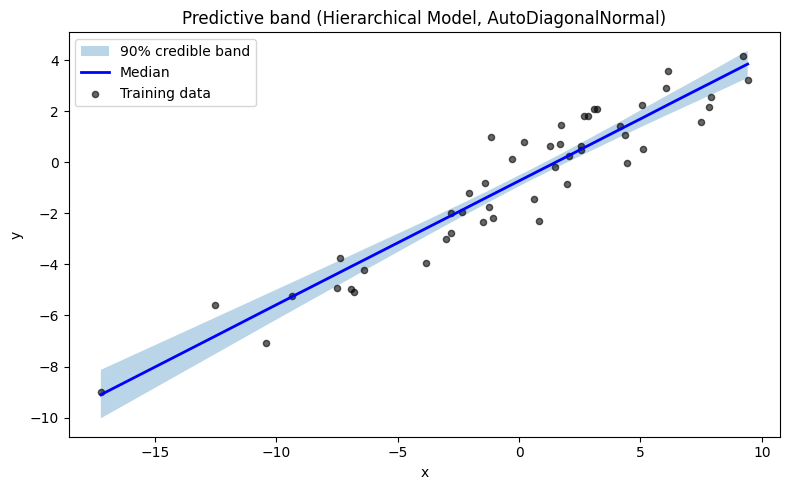

Empirical coverage of 90% predictive band (Hierarchical Model, AutoDiagonalNormal): 0.229
5th percentile of alpha (Hierarchical Model, AutoDiagonalNormal): -1.576
5th percentile of au (Hierarchical Model, AutoDiagonalNormal): 0.721
5th percentile of w (Hierarchical Model, AutoDiagonalNormal): 0.429
5th percentile of b (Hierarchical Model, AutoDiagonalNormal): -0.941
5th percentile of s (Hierarchical Model, AutoDiagonalNormal): 1.000
50th percentile of alpha (Hierarchical Model, AutoDiagonalNormal): -0.080
50th percentile of au (Hierarchical Model, AutoDiagonalNormal): 1.800
50th percentile of w (Hierarchical Model, AutoDiagonalNormal): 0.484
50th percentile of b (Hierarchical Model, AutoDiagonalNormal): -0.728
50th percentile of s (Hierarchical Model, AutoDiagonalNormal): 1.000
95th percentile of alpha (Hierarchical Model, AutoDiagonalNormal): 1.537
95th percentile of au (Hierarchical Model, AutoDiagonalNormal): 4.576
95th percentile of w (Hierarchical Model, AutoDiagonalNormal): 0.538

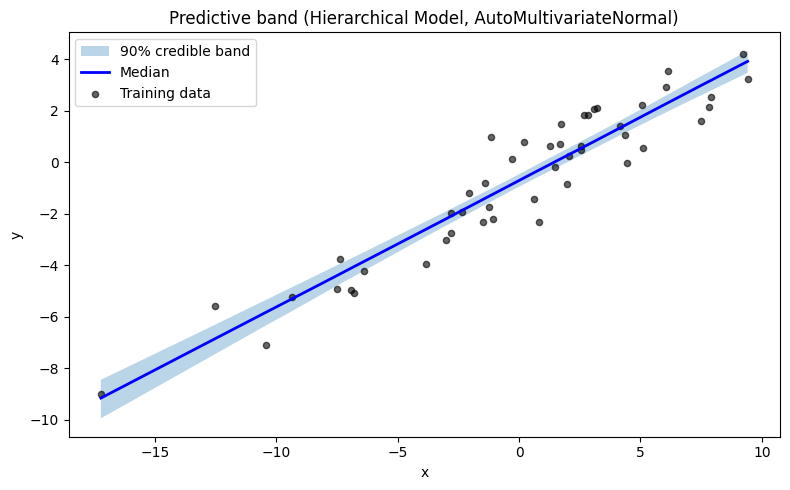

Empirical coverage of 90% predictive band (Hierarchical Model, AutoMultivariateNormal): 0.229
5th percentile of alpha (Hierarchical Model, AutoMultivariateNormal): -1.463
5th percentile of au (Hierarchical Model, AutoMultivariateNormal): 0.605
5th percentile of w (Hierarchical Model, AutoMultivariateNormal): 0.452
5th percentile of b (Hierarchical Model, AutoMultivariateNormal): -0.952
5th percentile of s (Hierarchical Model, AutoMultivariateNormal): 1.000
50th percentile of alpha (Hierarchical Model, AutoMultivariateNormal): 0.009
50th percentile of au (Hierarchical Model, AutoMultivariateNormal): 1.578
50th percentile of w (Hierarchical Model, AutoMultivariateNormal): 0.490
50th percentile of b (Hierarchical Model, AutoMultivariateNormal): -0.711
50th percentile of s (Hierarchical Model, AutoMultivariateNormal): 1.000
95th percentile of alpha (Hierarchical Model, AutoMultivariateNormal): 1.480
95th percentile of au (Hierarchical Model, AutoMultivariateNormal): 4.058
95th percentile o

In [29]:
pred_hier_auto = sample_posterior(hierarchical_model, svi_hier_auto, state_hier_auto, key1, x_tr, num_samples=1000, sites=["alpha", "au", "w", "b", "mu", "s"])
pred_hier_mv = sample_posterior(hierarchical_model, svi_hier_mv, state_hier_mv, key2, x_tr, num_samples=1000, sites=["alpha", "au", "w", "b", "mu", "s"])

# Quantiles
for model in ["AutoDiagonalNormal", "AutoMultivariateNormal"]:
    pred = pred_hier_auto if model == "AutoDiagonalNormal" else pred_hier_mv
    quantile1, quantile2, quantile3 = predictive_band_from_mu(pred['mu'])
    plot_predictive_band(x_tr, y_tr, quantile1, quantile2, quantile3, title=f'Predictive band (Hierarchical Model, {model})')
    coverage = coverage_from_mu(pred['mu'], y_tr, alpha=0.10)
    print(f"Empirical coverage of 90% predictive band (Hierarchical Model, {model}): {coverage:.3f}")
    for quantile in [5, 50, 95]:
        print(f"{quantile}th percentile of alpha (Hierarchical Model, {model}): {np.percentile(pred['alpha'], quantile):.3f}")
        print(f"{quantile}th percentile of au (Hierarchical Model, {model}): {np.percentile(pred['au'], quantile):.3f}")
        print(f"{quantile}th percentile of w (Hierarchical Model, {model}): {np.percentile(pred['w'], quantile):.3f}")
        print(f"{quantile}th percentile of b (Hierarchical Model, {model}): {np.percentile(pred['b'], quantile):.3f}")
        print(f"{quantile}th percentile of s (Hierarchical Model, {model}): {np.percentile(pred['s'], quantile):.3f}")

In [30]:
# Marginals
def plot_marginals(posterior_samples):
    dist_alpha = hv.Distribution(posterior_samples['alpha'], 'alpha')
    dist_au = hv.Distribution(posterior_samples['au'], 'au')
    dist_w = hv.Distribution(posterior_samples['w'], 'w')
    dist_b = hv.Distribution(posterior_samples['b'], 'b')
    dist_s = hv.Distribution(posterior_samples['s'], 's')
    return dist_alpha + dist_au + dist_w + dist_b + dist_s
plot_marginals(pred_hier_auto)
plot_marginals(pred_hier_mv)

:Layout
   .Distribution.I   :Distribution   [alpha]   (Density)
   .Distribution.II  :Distribution   [au]   (Density)
   .Distribution.III :Distribution   [w]   (Density)
   .Distribution.IV  :Distribution   [b]   (Density)
   .Distribution.V   :Distribution   [s]   (Density)

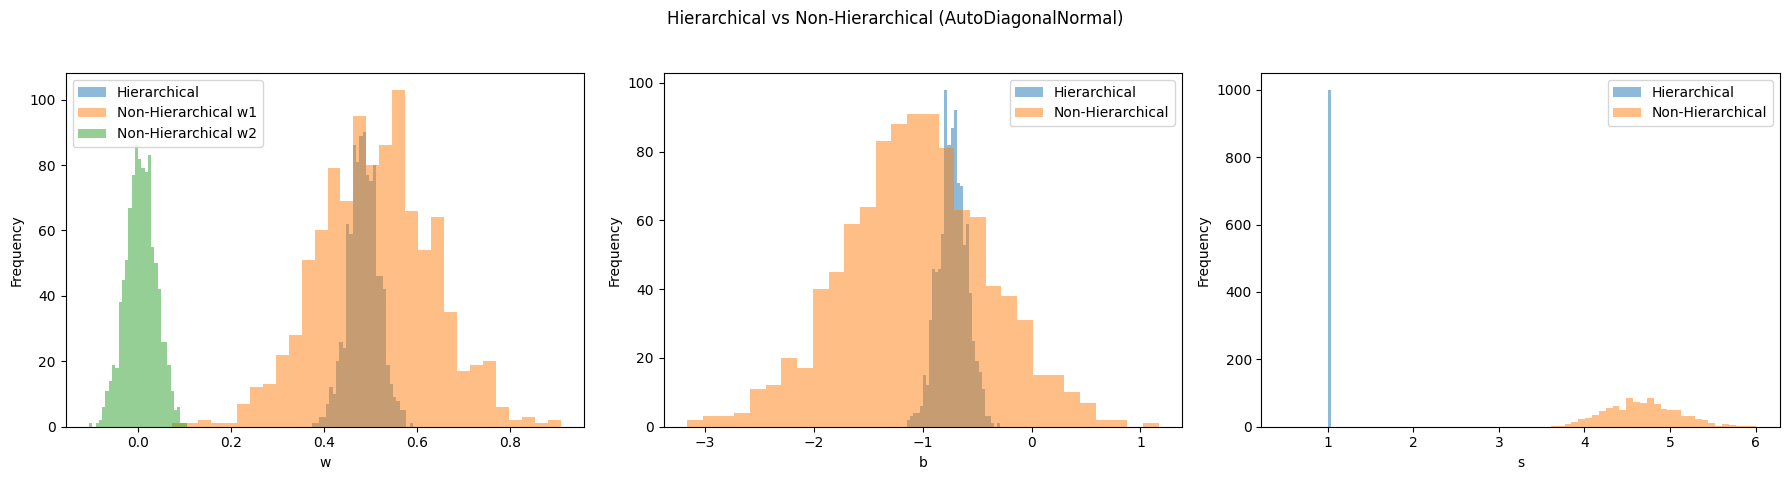

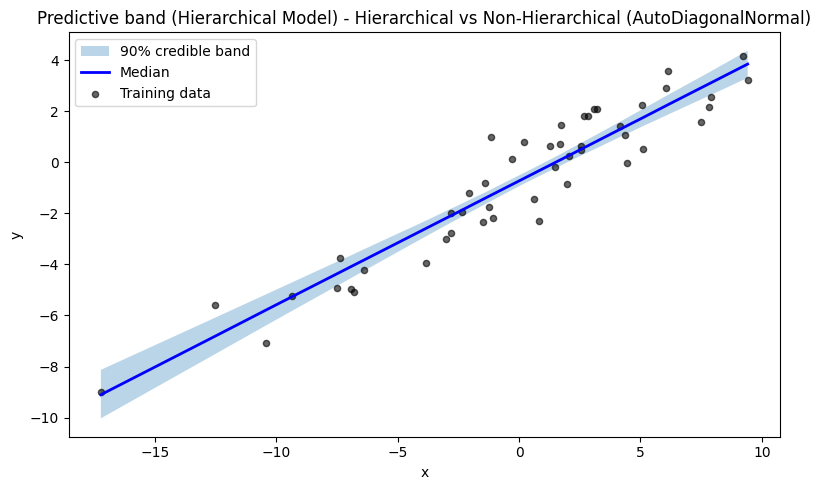

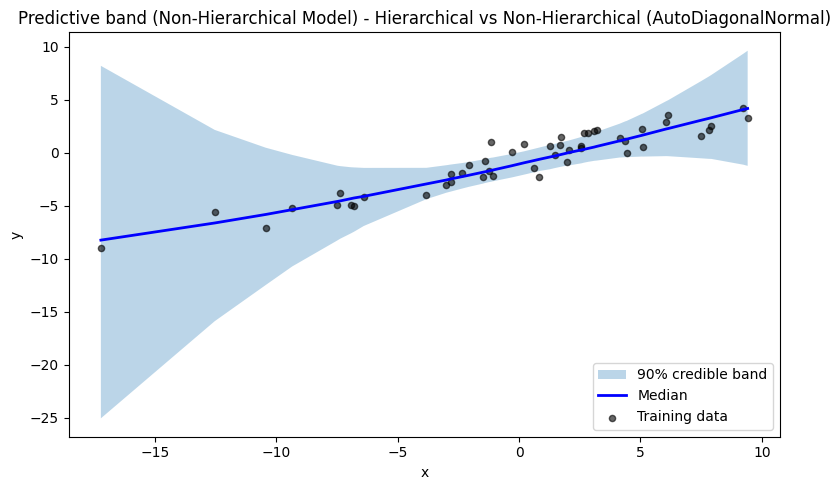

Empirical coverage of 90% predictive band (Hierarchical Model) - Hierarchical vs Non-Hierarchical (AutoDiagonalNormal): 0.229
Empirical coverage of 90% predictive band (Non-Hierarchical Model) - Hierarchical vs Non-Hierarchical (AutoDiagonalNormal): 0.812


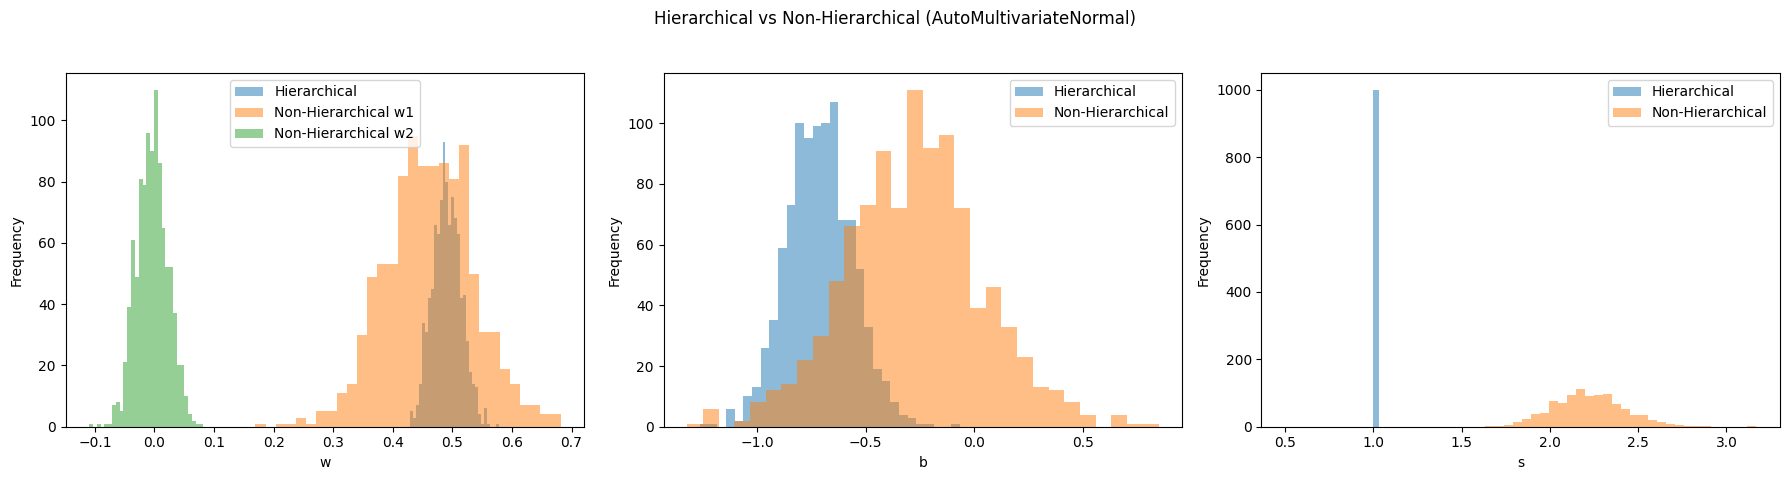

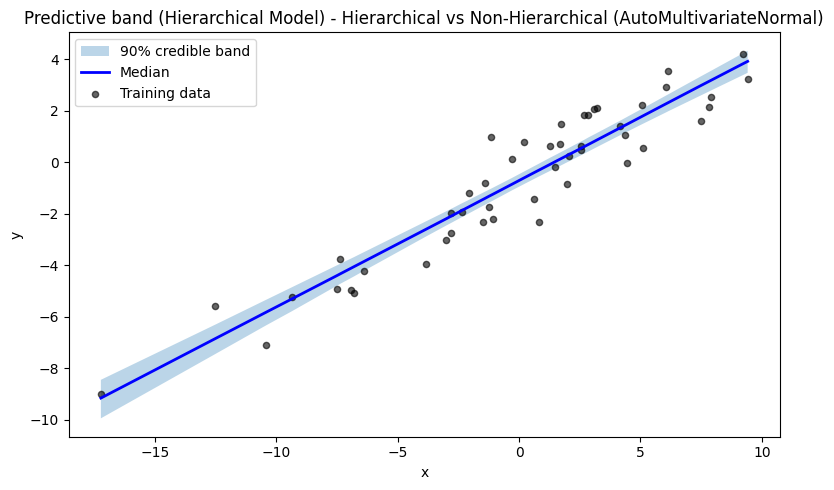

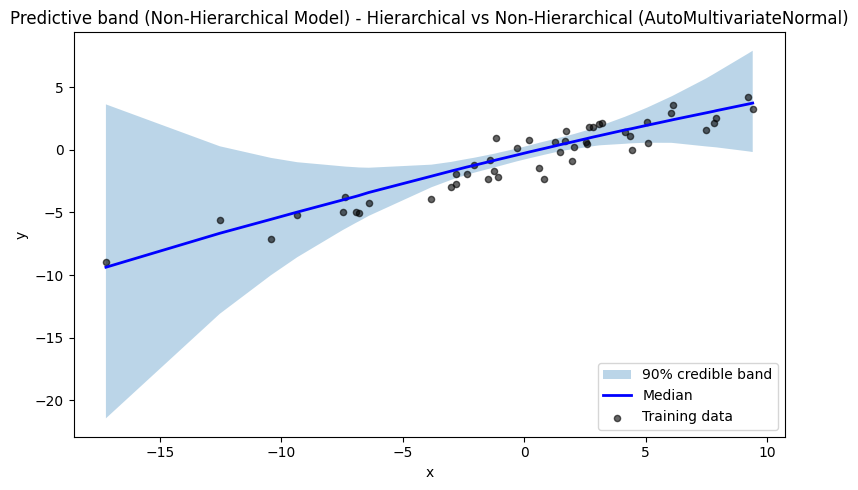

Empirical coverage of 90% predictive band (Hierarchical Model) - Hierarchical vs Non-Hierarchical (AutoMultivariateNormal): 0.229
Empirical coverage of 90% predictive band (Non-Hierarchical Model) - Hierarchical vs Non-Hierarchical (AutoMultivariateNormal): 0.583


In [35]:
# Compare: hierarchical vs non-hierarchical
def compare_hierarchical_nonhierarchical(pred_hier, pred_nonhier, title='Comparison of Hierarchical vs Non-Hierarchical'):
    plt.figure(figsize=(18, 5))
    plt.suptitle(title)
    
    # w comparison
    plt.subplot(1, 3, 1)
    plt.hist(pred_hier['w'], alpha=0.5, label='Hierarchical', bins=30)
    plt.hist(pred_nonhier['w1'], alpha=0.5, label='Non-Hierarchical w1', bins=30)
    plt.hist(pred_nonhier['w2'], alpha=0.5, label='Non-Hierarchical w2', bins=30)
    plt.xlabel('w')
    plt.ylabel('Frequency')
    plt.legend()
    
    # b comparison
    plt.subplot(1, 3, 2)
    plt.hist(pred_hier['b'], alpha=0.5, label='Hierarchical', bins=30)
    plt.hist(pred_nonhier['w0'], alpha=0.5, label='Non-Hierarchical', bins=30)
    plt.xlabel('b')
    plt.ylabel('Frequency')
    plt.legend()

    # Noise comparison
    plt.subplot(1, 3, 3)
    plt.hist(pred_hier['s'], alpha=0.5, label='Hierarchical', bins=30)
    plt.hist(pred_nonhier['s_eps'], alpha=0.5, label='Non-Hierarchical', bins=30)
    plt.xlabel('s')
    plt.ylabel('Frequency')
    plt.legend()
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    quantile1, quantile2, quantile3 = predictive_band_from_mu(pred_hier['mu'])
    plot_predictive_band(x_tr, y_tr, quantile1, quantile2, quantile3, title=f'Predictive band (Hierarchical Model) - {title}')
    coverage_hier = coverage_from_mu(pred_hier['mu'], y_tr, alpha=0.10)
    
    quantile1, quantile2, quantile3 = predictive_band_from_mu(pred_nonhier['mu'])
    plot_predictive_band(x_tr, y_tr, quantile1, quantile2, quantile3, title=f'Predictive band (Non-Hierarchical Model) - {title}')
    coverage_non_hier = coverage_from_mu(pred_nonhier['mu'], y_tr, alpha=0.10)

    print(f"Empirical coverage of 90% predictive band (Hierarchical Model) - {title}: {coverage_hier:.3f}")
    print(f"Empirical coverage of 90% predictive band (Non-Hierarchical Model) - {title}: {coverage_non_hier:.3f}")

pred_hier_auto = sample_posterior(hierarchical_model, svi_hier_auto, state_hier_auto, key1, x_tr, num_samples=1000, sites=["w", "b", "s", "mu"])
pred_hier_mv = sample_posterior(hierarchical_model, svi_hier_mv, state_hier_mv, key2, x_tr, num_samples=1000, sites=["w", "b", "s", "mu"])
compare_hierarchical_nonhierarchical(pred_hier_auto, pred_auto, title='Hierarchical vs Non-Hierarchical (AutoDiagonalNormal)')
compare_hierarchical_nonhierarchical(pred_hier_mv, pred_mv, title='Hierarchical vs Non-Hierarchical (AutoMultivariateNormal)')

### Observations:
* The prediction band for **non-hierarchical** baseline generally covers more samples (for both models).
* **AutoDiagonalNormal** has a higher coverage of its credible interval in case of a non-hierarchical model. 
* **Non-Hierarchical Models** have a wider distribution of their constant term (`b` / `w0`) and the noise factor (`s` / `s_eps`).

### Conclusion:
* **Non-Hierarchical** models are to robustly cover samples with a higher noise factor.